# EatWise Engine — Phase 1: Exploratory Data Analysis

**Project:** EatWise Engine — Personalised Dietary Recommendation Pipeline  
**Phase:** Phase 1 — Exploratory Data Analysis  
**Proposal cross-reference:** Section 3.1, Phase 1  
**Course:** BMET2925, University of Sydney  
**Authors:** EatWise Team  
**Date:** May 2026

## Section A: Notebook Setup and Load

Standard imports and display settings required for the EDA notebook.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)

Loading D1 and D4 cleaned CSVs; asserting expected shapes to confirm the correct files were loaded.

In [2]:
DATA_DIR = "cleaned_data/"

d1 = pd.read_csv(DATA_DIR + "d1_obesity_prediction_cleaned.csv")
d4 = pd.read_csv(DATA_DIR + "d4_personalised_medical_diet_cleaned.csv", keep_default_na=False, na_values=[""])

print(f"D1 shape: {d1.shape}")
print(f"D4 shape: {d4.shape}")

assert d1.shape == (2087, 17), f"D1 shape mismatch: expected (2087, 17), got {d1.shape}"
assert d4.shape == (5000, 30), f"D4 shape mismatch: expected (5000, 30), got {d4.shape}"

print("\nShape assertions passed.")

print("\nD4 Chronic_Disease value_counts (confirming 'None' is a category, not NaN):")
print(d4["Chronic_Disease"].value_counts(dropna=False))

D1 shape: (2087, 17)
D4 shape: (5000, 30)

Shape assertions passed.

D4 Chronic_Disease value_counts (confirming 'None' is a category, not NaN):
Chronic_Disease
None             2043
Diabetes         1019
Heart Disease     749
Hypertension      693
Obesity           496
Name: count, dtype: int64


Inspecting column data types for both datasets to identify which features are numeric vs categorical before analysis.

In [3]:
print("=== D1 dtypes ===")
print(d1.dtypes)
print("\n=== D4 dtypes ===")
print(d4.dtypes)

=== D1 dtypes ===
Gender             object
Age               float64
Height            float64
Weight            float64
family_history     object
FAVC               object
FCVC              float64
NCP               float64
CAEC               object
SMOKE              object
CH2O              float64
SCC                object
FAF               float64
TUE               float64
CALC               object
MTRANS             object
Obesity            object
dtype: object

=== D4 dtypes ===
Patient_ID                   object
Age                           int64
Gender                       object
Height_cm                     int64
Weight_kg                     int64
BMI                         float64
Chronic_Disease              object
Blood_Pressure_Systolic       int64
Blood_Pressure_Diastolic      int64
Cholesterol_Level             int64
Blood_Sugar_Level             int64
Genetic_Risk_Factor          object
Allergies                    object
Daily_Steps                   int64
Exe

Previewing the first few rows of each dataset to confirm column names, content, and that no obvious loading errors occurred.

In [4]:
print("=== D1 head ===")
display(d1.head())
print("\n=== D4 head ===")
display(d4.head())

=== D1 head ===


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



=== D4 head ===


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Chronic_Disease,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,Blood_Sugar_Level,Genetic_Risk_Factor,Allergies,Daily_Steps,Exercise_Frequency,Sleep_Hours,Alcohol_Consumption,Smoking_Habit,Dietary_Habits,Caloric_Intake,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Preferred_Cuisine,Food_Aversions,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats,Recommended_Meal_Plan
0,P00001,56,Other,163,66,24.84,None,175,75,219,124,No,None,11452,5,7.6,No,Yes,Vegetarian,2593,105,179,143,Western,None,2150,108,139,145,High-Protein Diet
1,P00002,69,Female,171,114,38.99,None,155,72,208,72,No,None,12962,1,6.3,Yes,No,Vegetarian,1852,69,315,75,Mediterranean,None,1527,74,266,80,Balanced Diet
2,P00003,46,Female,172,119,40.22,None,137,101,171,145,No,Gluten Intolerance,7898,3,9.9,No,No,Vegetarian,2737,183,103,148,Western,Sweet,2359,180,145,143,High-Protein Diet
3,P00004,32,Female,197,118,30.41,None,148,91,258,235,No,Nut Allergy,6602,5,4.2,No,No,Vegetarian,3289,135,371,120,Western,None,2858,137,378,135,High-Protein Diet
4,P00005,60,Female,156,109,44.79,Hypertension,160,109,260,248,Yes,None,9810,2,9.0,No,No,Regular,2405,167,298,48,Indian,Spicy,1937,166,317,56,High-Protein Diet


---

## Section B: Phase 1.1 — Univariate Distributions

Confirming available D4 column names before selecting features, to avoid using names that differ from the brief.

In [5]:
print("D4 columns:", d4.columns.tolist())

D4 columns: ['Patient_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Chronic_Disease', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Cholesterol_Level', 'Blood_Sugar_Level', 'Genetic_Risk_Factor', 'Allergies', 'Daily_Steps', 'Exercise_Frequency', 'Sleep_Hours', 'Alcohol_Consumption', 'Smoking_Habit', 'Dietary_Habits', 'Caloric_Intake', 'Protein_Intake', 'Carbohydrate_Intake', 'Fat_Intake', 'Preferred_Cuisine', 'Food_Aversions', 'Recommended_Calories', 'Recommended_Protein', 'Recommended_Carbs', 'Recommended_Fats', 'Recommended_Meal_Plan']


Defining feature lists and the shared plot helper; reusable across D1 and D4.

In [6]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

D1_CONTINUOUS = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE", "BMI"]

D4_CLINICAL = ["BMI", "Age", "Caloric_Intake", "Cholesterol_Level", "Blood_Pressure_Systolic", "Blood_Sugar_Level"]
D4_TARGETS  = ["Recommended_Calories", "Recommended_Protein", "Recommended_Carbs", "Recommended_Fats"]

def plot_hist_box(df, col, title_prefix=""):
    hist_fig = px.histogram(df, x=col, marginal="rug")
    box_fig  = px.box(df, y=col)

    fig = make_subplots(
        rows=1, cols=2,
        column_widths=[0.75, 0.25],
        subplot_titles=[f"{title_prefix}{col} — distribution", "box plot"]
    )
    for trace in hist_fig.data:
        fig.add_trace(trace, row=1, col=1)
    for trace in box_fig.data:
        fig.add_trace(trace, row=1, col=2)

    fig.update_layout(title_text=f"{title_prefix}{col}", showlegend=False, height=350)
    fig.show()

### D1 Univariate Distributions

Deriving BMI from Height and Weight for EDA only; not saved back to the cleaned CSV.

In [7]:
d1_eda = d1.copy()
d1_eda["BMI"] = d1_eda["Weight"] / (d1_eda["Height"] ** 2)
print(f"BMI range: {d1_eda['BMI'].min():.2f} – {d1_eda['BMI'].max():.2f}")

BMI range: 13.00 – 50.81


Plotting histogram with rug marks and box plot side-by-side for each D1 continuous feature to assess shape, spread, and outliers.

In [8]:
for col in D1_CONTINUOUS:
    plot_hist_box(d1_eda, col, title_prefix="D1 — ")

Computing skewness for all D1 continuous features; thresholding at |skew| > 0.5 to identify candidates for log compression in Phase 2.

In [9]:
d1_skew = d1_eda[D1_CONTINUOUS].skew().sort_values(key=abs, ascending=False)
print("D1 feature skewness (|skew| > 0.5 flagged):")
for col, v in d1_skew.items():
    flag = "  *** notable" if abs(v) > 0.5 else ""
    print(f"  {col:<10} {v:+.3f}{flag}")

D1 feature skewness (|skew| > 0.5 flagged):
  Age        +1.514  *** notable
  NCP        -1.138  *** notable
  TUE        +0.609  *** notable
  FAF        +0.494
  FCVC       -0.448
  Weight     +0.242
  BMI        +0.140
  CH2O       -0.106
  Height     -0.025


### D1 Skew Assessment and Log Compression Recommendation

Three features exceed the |skew| > 0.5 threshold (from the cell above). Whether log1p compression is appropriate depends on the feature type:

| Feature | Skew | Type | Recommendation |
|---|---|---|---|
| Age | +1.514 | Continuous | **log1p candidate** for linear and SVM models in Phase 2's four-model comparison. Random Forest is robust to skew and does not require this transform. |
| NCP | −1.138 | Discrete ordinal (1–4 scale) | **Leave untransformed.** log1p does not compress left skew, and log transformation is not meaningful on a 1–4 ordinal range. |
| TUE | +0.609 | Discrete ordinal (0–2 scale) | **Leave untransformed.** Same reasoning as NCP. |

The remaining features — FAF, FCVC, CH2O (discrete ordinal), Weight, BMI, Height (continuous, low skew) — require no transformation.

**Phase 2 prep guidance:** Apply log1p to Age for linear and SVM pipelines only. All discrete ordinal features (FCVC, NCP, CH2O, FAF, TUE) are left untransformed regardless of skew. The cleaned CSV is unchanged.

### D4 Univariate Distributions (Light Scope)

Plotting D4 clinical input features to characterise the patient population prior to examining the regression targets.

In [10]:
for col in D4_CLINICAL:
    plot_hist_box(d4, col, title_prefix="D4 clinical — ")

Plotting the four D4 regression targets; their shape determines whether target transformation will be needed in Phase 3.

In [11]:
for col in D4_TARGETS:
    plot_hist_box(d4, col, title_prefix="D4 target — ")

Computing skewness for the four D4 regression targets; skew will inform whether a transformed target is needed in Phase 3.

In [12]:
d4_target_skew = d4[D4_TARGETS].skew().sort_values(key=abs, ascending=False)
print("D4 regression target skewness (|skew| > 0.5 flagged):")
for col, v in d4_target_skew.items():
    flag = "  *** notable" if abs(v) > 0.5 else ""
    print(f"  {col:<25} {v:+.3f}{flag}")

print("\nD4 regression target descriptive stats:")
display(d4[D4_TARGETS].describe().round(2))

D4 regression target skewness (|skew| > 0.5 flagged):
  Recommended_Protein       -0.017
  Recommended_Fats          -0.014
  Recommended_Carbs         +0.013
  Recommended_Calories      -0.001

D4 regression target descriptive stats:


,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats
count,5000.00,5000.00,5000.00,5000.00
mean,2046.24,129.29,248.33,89.03
std,671.38,43.91,91.15,38.34
min,725.00,40.00,50.00,10.00
25%,1478.00,92.00,173.00,56.00
50%,2044.00,129.00,246.00,89.00
75%,2621.00,166.00,324.00,121.00
max,3372.00,218.00,447.00,168.00


### D4 Regression Target Skew Assessment

All four regression targets have near-zero skew (from the cell above): Recommended_Protein (−0.017), Recommended_Fats (−0.014), Recommended_Carbs (+0.013), Recommended_Calories (−0.001). None exceed the |0.5| threshold. The distributions are approximately uniform across their respective ranges, consistent with synthetic data generation. No target transformation (e.g. log-link) is required for Phase 3 regression.

---

## Section C: Phase 1.2 — Class Balance

### D1 Class Balance — `Obesity` (7 classes)

Visualising class balance using matplotlib (per proposal Phase 1.2); imbalance informs whether `class_weight='balanced'` is needed in Phase 2.

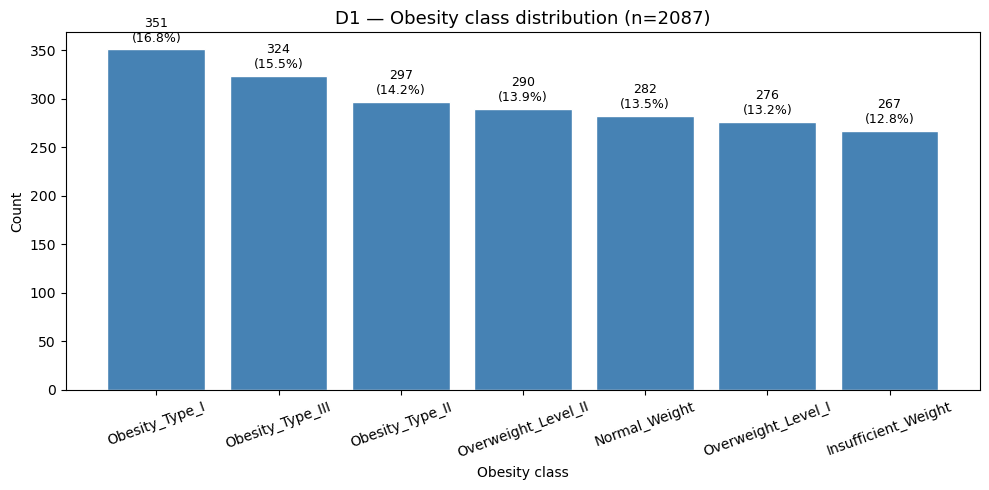


D1 Obesity value counts:
                     count   pct
Obesity                         
Obesity_Type_I         351  16.8
Obesity_Type_III       324  15.5
Obesity_Type_II        297  14.2
Overweight_Level_II    290  13.9
Normal_Weight          282  13.5
Overweight_Level_I     276  13.2
Insufficient_Weight    267  12.8


In [13]:
d1_counts = d1["Obesity"].value_counts().sort_values(ascending=False)
d1_pct    = (d1_counts / len(d1) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(d1_counts.index, d1_counts.values, color="steelblue", edgecolor="white")

for bar, count, pct in zip(bars, d1_counts.values, d1_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{count}\n({pct}%)",
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("D1 — Obesity class distribution (n=2087)", fontsize=13)
ax.set_xlabel("Obesity class")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print("\nD1 Obesity value counts:")
print(pd.DataFrame({"count": d1_counts, "pct": d1_pct}))

**D1 class balance verdict:** Balanced — 4.0 pp spread across 7 classes (12.8%–16.8%). Class imbalance not a concern for Phase 2 training.

### D4 Class Balance — `Recommended_Meal_Plan` (4 classes)

Same matplotlib pattern; verdict will feed into Phase 3 classification modelling decisions.

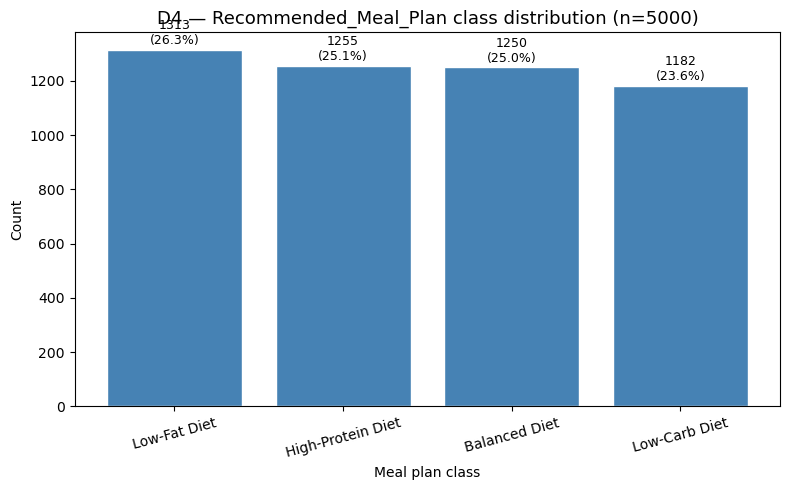


D4 Recommended_Meal_Plan value counts:
                       count   pct
Recommended_Meal_Plan             
Low-Fat Diet            1313  26.3
High-Protein Diet       1255  25.1
Balanced Diet           1250  25.0
Low-Carb Diet           1182  23.6


In [14]:
d4_counts = d4["Recommended_Meal_Plan"].value_counts().sort_values(ascending=False)
d4_pct    = (d4_counts / len(d4) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(d4_counts.index, d4_counts.values, color="steelblue", edgecolor="white")

for bar, count, pct in zip(bars, d4_counts.values, d4_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{count}\n({pct}%)",
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("D4 — Recommended_Meal_Plan class distribution (n=5000)", fontsize=13)
ax.set_xlabel("Meal plan class")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

print("\nD4 Recommended_Meal_Plan value counts:")
print(pd.DataFrame({"count": d4_counts, "pct": d4_pct}))

**D4 class balance verdict:** Balanced — 2.7 pp spread across 4 classes (23.6%–26.3%). Class imbalance not a concern for Phase 3 training.

---

## Section D: Phase 1.3 — Imputation Review

### D1 Missing Value Check

Asserting zero missing values in D1; the cleaning notebook confirmed no imputation was required for this dataset.

In [15]:
d1_missing = d1.isna().sum().sum()
print(f"D1 total missing values: {d1_missing}")
assert d1_missing == 0, f"Expected 0 missing values, got {d1_missing}"
print("Assertion passed.")

D1 total missing values: 0
Assertion passed.


D1 had zero missing values prior to cleaning and required no imputation. All 2087 rows are complete.

### D4 Categorical Missingness Review

Inspecting `Chronic_Disease`, `Allergies`, and `Food_Aversions` to confirm that blank fields were recoded to the string `"None"` during cleaning, not left as NaN.

Printing value_counts (dropna=False) for the three categorical columns to verify "None" is present as a category rather than absorbed into NaN.

In [16]:
for col in ["Chronic_Disease", "Allergies", "Food_Aversions"]:
    print(f"\n{col}:")
    print(d4[col].value_counts(dropna=False).to_string())


Chronic_Disease:
Chronic_Disease
None             2043
Diabetes         1019
Heart Disease     749
Hypertension      693
Obesity           496

Allergies:
Allergies
None                   3497
Lactose Intolerance     556
Nut Allergy             483
Gluten Intolerance      464

Food_Aversions:
Food_Aversions
Spicy    1263
Sweet    1262
Salty    1250
None     1225


The output above confirms that `"None"` appears as an explicit string category in all three columns — no NaN entries are present. This is the intended representation from the cleaning step, which recoded blank fields to `"None"` under the **"missingness as information"** principle (Lecture 3.4, p.10): a blank allergy field implies the patient has no allergy, not that the value is unknown. Imputing the mode (e.g. "Lactose Intolerance" for Allergies) would incorrectly restrict food choices for patients who have none.

---

## Section E: Bivariate and Multivariate Analysis

### Scatter Matrix

Scatter matrix of all D1 continuous features coloured by Obesity class to reveal pairwise structure and any visible class separation across feature combinations.

In [17]:
fig = px.scatter_matrix(
    d1_eda,
    dimensions=D1_CONTINUOUS,
    color="Obesity",
    title="D1 — Scatter matrix of continuous features coloured by Obesity class (n=2087)",
    height=900,
)
fig.update_traces(marker=dict(size=2, opacity=0.5), diagonal_visible=False)
fig.show()

### Pearson Correlation Heatmap

Pearson correlation measures linear association between continuous features; used to identify strongly correlated pairs that may cause multicollinearity in linear Phase 2 models.

In [18]:
pearson_r = d1_eda[D1_CONTINUOUS].corr(method="pearson")

fig = px.imshow(
    pearson_r,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    title="D1 — Pearson correlation heatmap (continuous features)",
    aspect="auto",
)
fig.update_layout(height=600)
fig.show()

print("\nPearson pairs with |r| > 0.7:")
checked = set()
for col_a in D1_CONTINUOUS:
    for col_b in D1_CONTINUOUS:
        if col_a >= col_b:
            continue
        r = pearson_r.loc[col_a, col_b]
        if abs(r) > 0.7:
            print(f"  {col_a} — {col_b}: r = {r:.3f}")


Pearson pairs with |r| > 0.7:
  BMI — Weight: r = 0.934


### Spearman Correlation Heatmap

Spearman correlation captures monotonic (not just linear) associations; comparing it to Pearson reveals whether relationships are linear or whether non-linearity is present.

In [19]:
spearman_r = d1_eda[D1_CONTINUOUS].corr(method="spearman")

fig = px.imshow(
    spearman_r,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    title="D1 — Spearman correlation heatmap (continuous features)",
    aspect="auto",
)
fig.update_layout(height=600)
fig.show()

print("\nSpearman pairs with |r| > 0.7:")
for col_a in D1_CONTINUOUS:
    for col_b in D1_CONTINUOUS:
        if col_a >= col_b:
            continue
        r = spearman_r.loc[col_a, col_b]
        if abs(r) > 0.7:
            print(f"  {col_a} — {col_b}: rho = {r:.3f}")

print("\nPearson vs Spearman delta (|delta| > 0.1 flagged):")
for col_a in D1_CONTINUOUS:
    for col_b in D1_CONTINUOUS:
        if col_a >= col_b:
            continue
        delta = spearman_r.loc[col_a, col_b] - pearson_r.loc[col_a, col_b]
        if abs(delta) > 0.1:
            print(f"  {col_a} — {col_b}: Pearson={pearson_r.loc[col_a,col_b]:.3f}, Spearman={spearman_r.loc[col_a,col_b]:.3f}, delta={delta:+.3f}")


Spearman pairs with |r| > 0.7:
  BMI — Weight: rho = 0.929

Pearson vs Spearman delta (|delta| > 0.1 flagged):
  Age — Weight: Pearson=0.198, Spearman=0.350, delta=+0.152
  Age — BMI: Pearson=0.241, Spearman=0.395, delta=+0.155
  NCP — Weight: Pearson=0.092, Spearman=-0.012, delta=-0.104


### Multicollinearity Flags and Pearson vs Spearman Comparison

**Multicollinearity flags (|r| > 0.7, from cell outputs above):**

One pair exceeds the threshold in both matrices:

- **BMI — Weight: Pearson r = 0.934, Spearman ρ = 0.929.** This is a deterministic-derivation correlation, not a discovered relationship: BMI is computed as Weight / Height², so a strong positive correlation with Weight is structurally guaranteed. This pair is flagged as a multicollinearity candidate but the correct response is not feature selection between them — it is the Phase 2 decision to drop both Height and Weight before training (documented in Section F), retaining only BMI as the summary measure.

No other pair exceeds |r| > 0.7 in either heatmap.

**Pearson vs Spearman comparison:**

The two matrices agree closely on the dominant relationship (BMI–Weight) and on the near-zero correlations among lifestyle features, but Spearman gives notably higher coefficients than Pearson for Age–Weight (+0.152 delta) and Age–BMI (+0.155 delta), indicating that the Age–adiposity relationship is monotonic but non-linear — consistent with the right-skewed Age distribution seen in Section B. NCP–Weight shows a sign flip between Pearson and Spearman, attributable to Pearson's sensitivity to the sparse NCP=1 tail of the discrete ordinal distribution rather than to outliers (these values were explicitly retained as valid responses in cleaning Section 1.4).

---
## Section F: Phase 2 Prep Notes

Re-running the BMI band check from cleaning section 1.8 to count rows where the computed BMI does not fall within the band corresponding to the labelled Obesity class; these are label-noise rows proposed for removal before Phase 2 training.

In [20]:
# WHO/standard BMI band boundaries for the 7 Obesity classes
BMI_BANDS = {
    "Insufficient_Weight":  (0,    18.5),
    "Normal_Weight":        (18.5, 25.0),
    "Overweight_Level_I":   (25.0, 27.5),
    "Overweight_Level_II":  (27.5, 30.0),
    "Obesity_Type_I":       (30.0, 35.0),
    "Obesity_Type_II":      (35.0, 40.0),
    "Obesity_Type_III":     (40.0, float("inf")),
}

def in_band(row):
    lo, hi = BMI_BANDS[row["Obesity"]]
    return lo <= row["BMI"] < hi

d1_eda["bmi_in_band"] = d1_eda.apply(in_band, axis=1)
mismatched = d1_eda[~d1_eda["bmi_in_band"]]

print(f"Total rows:              {len(d1_eda)}")
print(f"BMI-band mismatches:     {len(mismatched)} ({len(mismatched)/len(d1_eda)*100:.2f}%)")
print(f"\nBreakdown by labelled Obesity class:")
print(mismatched["Obesity"].value_counts().to_string())

Total rows:              2087
BMI-band mismatches:     170 (8.15%)

Breakdown by labelled Obesity class:
Obesity
Overweight_Level_II    66
Obesity_Type_III       56
Overweight_Level_I     18
Obesity_Type_II        18
Obesity_Type_I          5
Insufficient_Weight     4
Normal_Weight           3


### Decision 1 — Remove 170 BMI-band-mismatched rows before Phase 2 training

The band check above identifies **170 rows (8.15%)** where the recomputed BMI does not fall within the WHO band corresponding to the labelled `Obesity` class. These are label-noise rows: the survey-reported Height and Weight are internally inconsistent with the assigned class label.

Breakdown by labelled class (from cell above):

| Labelled class | Mismatched rows |
|---|---|
| Overweight_Level_II | 66 |
| Obesity_Type_III | 56 |
| Overweight_Level_I | 18 |
| Obesity_Type_II | 18 |
| Obesity_Type_I | 5 |
| Insufficient_Weight | 4 |
| Normal_Weight | 3 |

**Proposed action for Phase 2:** Drop these 170 rows before training. The remaining 1917 rows have consistent BMI–label alignment. This removal is applied to the training copy only; no change to the cleaned CSV.

---

### Decision 2 — Drop Height and Weight from D1 before Phase 2 training

BMI is a deterministic function of Height and Weight (BMI = Weight / Height²), and the 7-class `Obesity` target is itself derived from BMI bands. Retaining Height and Weight alongside BMI would allow the classifier to reconstruct the BMI threshold function directly — learning the arithmetic of the label rather than the lifestyle drivers of obesity.

**Proposed action for Phase 2:** Drop `Height` and `Weight` from the feature matrix before training. The classifier will learn from the remaining lifestyle features: FCVC, NCP, CAEC, CH2O, FAF, TUE, FAVC, SMOKE, SCC, CALC, MTRANS, `family_history`, `Gender`, `Age`, and the retained `BMI`. This is consistent with the proposal scope and is reinforced by the Pearson r = 0.934 multicollinearity flag identified in Section E.

---
## Section G: Headline Findings Summary

Among D1 continuous features, Age (+1.514), NCP (−1.138), and TUE (+0.609) show notable skew; Height, Weight, BMI, FCVC, CH2O, and FAF are approximately symmetric (skewness cell, Section B). D1's seven Obesity classes are balanced, spanning 12.8% (Insufficient_Weight, n=267) to 16.8% (Obesity_Type_I, n=351) — a 4.0 pp range — and class imbalance is not a concern for Phase 2 training (class balance cell, Section C). The strongest Pearson correlation is BMI–Weight (r=0.934), which is a deterministic-derivation relationship rather than a discovered one; the only meaningful Pearson–Spearman divergence is on Age–Weight and Age–BMI (Spearman exceeds Pearson by +0.152 and +0.155 respectively), indicating a monotonic but non-linear age–adiposity relationship (heatmap cells, Section E). The four D4 regression targets (Recommended_Calories, Recommended_Protein, Recommended_Carbs, Recommended_Fats) all have |skew| < 0.02 and span well-defined numeric ranges, and no target transformation is required for Phase 3 regression (skew cell, Section B). D4's four Recommended_Meal_Plan classes are balanced, spanning 23.6% (Low-Carb Diet, n=1182) to 26.3% (Low-Fat Diet, n=1313) — a 2.7 pp range — and class imbalance is not a concern for Phase 3 training (class balance cell, Section C). For Phase 2, 170 BMI-band-mismatched rows (8.15%) are proposed for removal before training, and Height and Weight are proposed for exclusion from the feature matrix so the classifier learns from lifestyle features rather than the BMI derivation formula (band-check cell and Section F).